# Pattern Recognition 2 - Feature Space

**Objectives**

* Compute distances between objects in feature space
* Use PCA to perform reduce the dimensionality of the problem
* Implement face recognition using [Eigenfaces](http://en.wikipedia.org/wiki/Eigenface)

## Feature space distance

The `ocr_features.npy` file contains extracted features for each letter from the document used in the previous lab, and the `ocr_class.npy` file contains the character corresponding to these features.

The 18 features, extracted with the `regionprops` methods from `scikit-image` are, in order: 

> area, convex area, eccentricity, equivalent diameter, extent, filled area, intertia tensor eigenvalue 1, inertia tensor eigenvalue 2, major axis length, minor axis length, Hu moment 1, Hu moment 2, Hu moment 3, Hu moment 4, Hu moment 5, Hu moment 6, perimeter, solidity

* Create a method which computes the Euclidian distance, in feature space, between two objects.
* Check if the "nearest" object is of the same class.
* What can you do to improve this "distance-based" classification? 

In [1]:
import numpy as np

ocr_features = np.load('../extern_data/ocr_features.npy')
ocr_class = np.load('../extern_data/ocr_class.npy')

print(ocr_features.shape)
print(np.unique(ocr_class))

(2392, 18)
['0' '1' '4' '5' 'A' 'B' 'C' 'D' 'F' 'G' 'I' 'L' 'M' 'N' 'O' 'R' 'S' 'T'
 'W' 'a' 'b' 'c' 'd' 'e' 'f' 'g' 'h' 'i' 'k' 'l' 'm' 'n' 'o' 'p' 'q' 'r'
 's' 't' 'u' 'v' 'w' 'x' 'y' 'z']


In [2]:

## -- Your code here -- ##

# ------------------------------------------- EUCLIDIAN DISTANCE
def Euclidian_distance(obj1, obj2):
    distance = np.sqrt( np.sum( (obj2 - obj1)**2 ) )

    return distance

obj0 = ocr_features[0]
min_dist_obj = ocr_features[1]
min_dist_pos = 1

dist = Euclidian_distance(obj0, min_dist_obj)
print(f"DISTANCE between object 0 and 1 : {dist}\n")


# ------------------------------------------- CHECK NEAREST OBJECT'S CLASS
min_dist = dist
for i in range (2, len(ocr_features)):
    dist = Euclidian_distance(obj0, ocr_features[i])

    if(dist < min_dist):
        min_dist = dist
        min_dist_obj = ocr_features[i]
        min_dist_pos = i


print(f"Nearest object to Object 0 : Object {min_dist_pos}\nDISTANCE : {min_dist}")

print(f"Class Object 0 -> {ocr_class[0]}\nClass Object {min_dist_pos} -> {ocr_class[min_dist_pos]}")
if (ocr_class[0] == ocr_class[min_dist_pos]):
    print(f"The 2 objects have the same class '{ocr_class[0]}' !")


""" What can you do to improve this "distance-based" classification? --> We can normalize the data / make Dimensionality Reduction  """





DISTANCE between object 0 and 1 : 82.91159709088073

Nearest object to Object 0 : Object 1377
DISTANCE : 0.0
Class Object 0 -> i
Class Object 1377 -> i
The 2 objects have the same class 'i' !


' What can you do to improve this "distance-based" classification? --> We can normalize the data / make Dimensionality Reduction  '

## Eigenfaces

The `faces.npy` file contains a 3D matrix containing 2963 images, each with 170x200 pixels, encoded in 8-bit grayscale.

In [3]:
from matplotlib import pyplot as plt
%matplotlib inline

faces = np.load('../extern_data/faces.npy')
print(faces.shape, faces.dtype, faces.min(), faces.max())

(2963, 200, 170) uint8 0 255


C:\Users\OxFri\AppData\Local\Temp\ipykernel_53796\520583373.py:4: UserWarning: Reading `.npy` or `.npz` file required additional header parsing as it was created on Python 2. Save the file again to speed up loading and avoid this warning.
  faces = np.load('../extern_data/faces.npy')


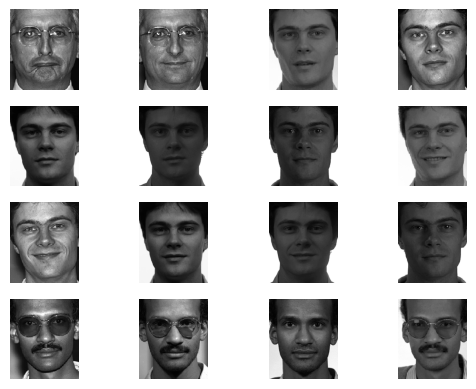

In [4]:
# Show some faces:
plt.figure()
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(faces[i], cmap=plt.cm.gray)
    plt.axis('off')
plt.show()

### Direct approach

1. Write a program that subsample the images (e.g. by 5), converts 2D images into lines, and collect all these lines into one single matrix **T**.
1. Zero-center **T** by removing the "mean image" ($T_i \leftarrow T_i - T_{mean}$)
1. Compute the variance/covariance matrix of **T**:
$$ \mathbf{S} = \mathbf{T^TT}$$
1. Compute the eigenvalues $\lambda_i$ and eigenvectors $\mathbf{v}_i$ of **S**
$$\mathbf{Sv}_i = \mathbf{T^T}\mathbf{Tv}_i = \lambda_i \mathbf{v}_i$$
1. The eigenvectors have the same size as the images, and are often referred to as "eigenfaces". Display some of them.

In [5]:
# Example of eigen value extraction
import numpy as np
from numpy import linalg as LA

w,v = LA.eig(np.diag((1, 2, 3)))
print(w,v)

[1. 2. 3.] [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


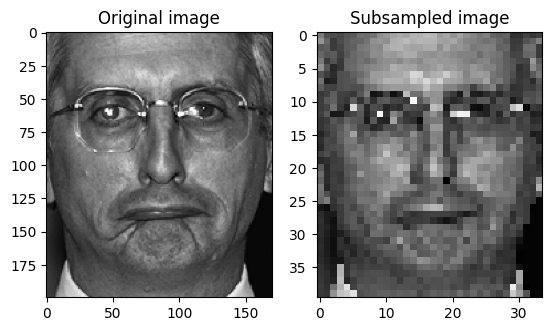

In [6]:
# Example of subsampling
im = faces[0]
plt.figure()
plt.subplot(1,2,1)
plt.imshow(im, cmap=plt.cm.gray)
plt.title("Original image")
plt.subplot(1,2,2)
plt.imshow(im[::5,::5], cmap=plt.cm.gray)
plt.title("Subsampled image")
plt.show()

T: (2963, 1360)
S: (1360, 1360)
Number of Eigen Values: 1360
Matrix of Eigen Vectors: (1360, 1360)
[1.80905304e+09 1.40572718e+09 4.94243359e+08 ... 1.38025985e+04
 1.35065282e+04 1.30070946e+04] 



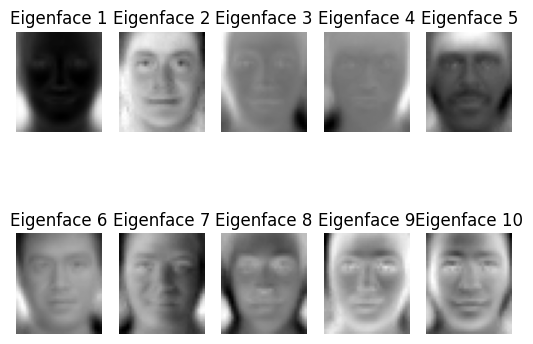

In [38]:

## -- Your code here -- ##

# ------------------------------------------- 1/ SUBSAMPLING
T = []

for face in faces:

    # Subsampling + 2D matrix into 1D vector
    line = face[::5, ::5].flatten()
    
    T.append(line)

T = np.array(T)
print(f"T: {T.shape}")

# ------------------------------------------- 2/ ZERO CENTERING T (remove T-mean)

T_mean = np.mean(T, axis=0) #Mean for every column of T

T_centered = T - T_mean

# ------------------------------------------- 3/ VARIANCE/COVARIANCE MATRIX

S = T_centered.T @ T_centered

print(f"S: {S.shape}")

# ------------------------------------------- 4/ EIGENVALUES & EIGENVECTORS


w,v = LA.eig(S)

print(f"Number of Eigen Values: {len(w)}")
print(f"Matrix of Eigen Vectors: {v.shape}")

# descending sorted w indices
indices = np.argsort(w)[::-1]

# descending sorted eigenvalues
w_sorted = w[indices]

#descending sorted eigenvectors
v_sorted = v[:, indices]

print(w_sorted, "\n")


# ------------------------------------------- 5/ DISPLAY EIGENFACES
shape2D = faces[0][::5, ::5].shape

plt.figure()

for i in range(10):
    plt.subplot(2, 5, i+1)

    eigenFace2D = v_sorted[:, i].reshape(shape2D)   # 1D vector -> 2D matrix

    plt.imshow(eigenFace2D, cmap=plt.cm.gray)
    plt.title(f"Eigenface {i+1}")
    plt.axis("off")

plt.show()

### Compression

1. Reconstruct images using only the first N eigenfaces (e.g. N=100).
2. Compare (visually) reconstructed images with original images

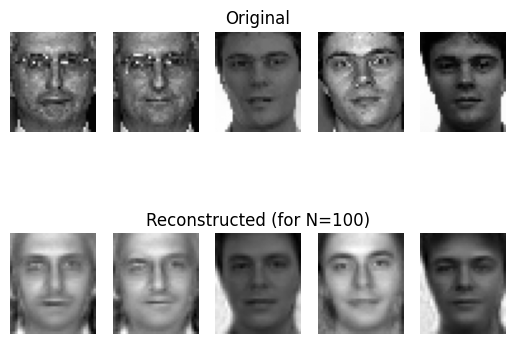

In [ ]:

## -- Your code here -- ##
N = 100

# Keep the N first Eigenfaces
v_N = v_sorted[:, :N]

# Projection
weights = T_centered @ v_N

# Reconstruction
reconstructed_faces_centered = weights @ (v_N).T

# Re-add the mean face 'T_mean'
reconstructed_faces = reconstructed_faces_centered + T_mean

# DISPLAY RECONSTRUCTED vs ORIGINAL IMAGES
plt.figure()


# titles for each row
plt.subplot(2, 5, 3)    
plt.title("Original")

plt.subplot(2, 5, 3 + 5)    
plt.title(f"Reconstructed (for N={N})")

for i in range(5):
    # ORIGINAL IMAGES (1st row)
     plt.subplot(2, 5, i+1)
     original2D = T[i].reshape(shape2D)
     plt.imshow(original2D, cmap=plt.cm.gray)
     plt.axis("off")

    # RECONSTRUCTED IMAGES (2nd row)
     plt.subplot(2, 5, i+1 + 5)
     reconstructed2D = reconstructed_faces[i].reshape(shape2D)
     plt.imshow(reconstructed2D, cmap=plt.cm.gray)
     plt.axis("off")



plt.show()



### Face recognition

1. Using the simplified vector space (e.g. 100 first eigenfaces), compute the euclidian distance between one face and the others.
2. For a subset of the image of the database, find the 4 closest matches.

The closest matches are images [   1  443 1062  442]


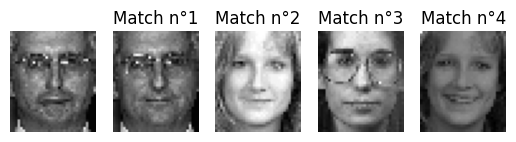

In [81]:

## -- Your code here -- ##
face0 = weights[0]

distances = []

for i in range(len(weights)):
    dist = Euclidian_distance(face0, weights[i])

    distances.append(dist)

distances = np.array(distances)

# get the indices from the closest matches
best_dist_indices = np.argsort(distances)

print(f"The closest matches are images {best_dist_indices[1:5]}")

plt.figure()

# COMPARED IMAGE
plt.subplot(1,5,1)
img = T[0].reshape(shape2D)
plt.imshow(img, cmap=plt.cm.gray)
plt.axis("off")

i = 1

for index in best_dist_indices[1:5]:
    # CLOSEST MATCHES
    plt.subplot(1,5, i + 1)
    img = T[index].reshape(shape2D)
    plt.imshow(img, cmap=plt.cm.gray)
    plt.title(f"Match n°{i}")
    plt.axis("off")


    i += 1


plt.show()




### Indirect approach

Instead of using the eigenvalues/eigenvectors of $\mathbf{S} = \mathbf{T^TT}$, compute the the eigenvalues/eigenvectors of $\mathbf{Q} = \mathbf{TT^T}$.

Let $\mathbf{u_i}$ be the eigenvectors of $\mathbf{Q}$. We have:
$$\mathbf{TT^T}\mathbf{u}_i = \lambda_i \mathbf{u}_i$$

By multiplying to the left with $\mathbf{T^T}$, we have:
$$\mathbf{T^T}\mathbf{TT^T}\mathbf{u}_i = \lambda_i\mathbf{T^T}\mathbf{u}_i$$
$$\mathbf{S}\mathbf{T^T}\mathbf{u}_i = \lambda_i\mathbf{T^T}\mathbf{u}_i$$

Which means that if $\mathbf{u}_i$ is eigenvector of $\mathbf{Q}$, then $\mathbf{T^T}\mathbf{u}_i$ is eigenvector of $\mathbf{S}$.

The indirect approach thus becomes:
1. Compute the eigenvectors $\mathbf{u}_i$ of $\mathbf{Q} = \mathbf{TT^T}$.
1. Compute the eigenfaces with $\mathbf{v}_i = \mathbf{T^T}\mathbf{u}_i$ 
1. Reconstruct the images using only the first N eigenfaces (e.g. N=100)
1. Compare (visually) reconstructed images with original images
1. Use the indirect approach with more resolution (without subsampling the images)

Use this new feature space to perform the same face recognition method.

T_full: (2963, 34000)
Q: (2963, 2963)


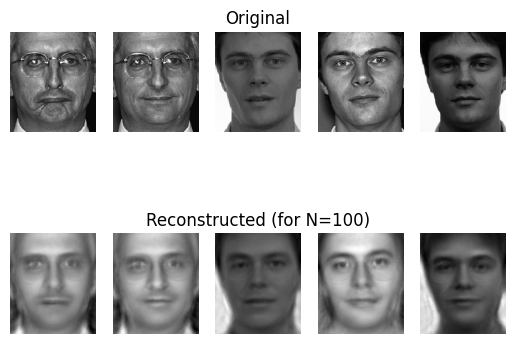

The closest matches are images [  1 758   3 443]


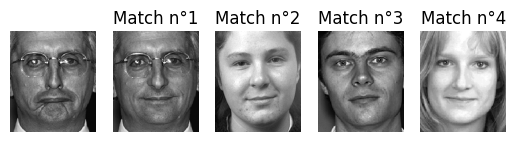

In [97]:

## -- Your code here -- ##

# ------------------------------------------- FLATTENING & ZERO CENTERING
T_full = []

for face in faces:
    T_full.append(face.flatten())

T_full = np.array(T_full)

T_mean_full = np.mean(T_full, axis=0)
T_centered_full = T_full - T_mean_full

print(f"T_full: {T_full.shape}")


# ------------------------------------------- INDIRECT APPROACH
Q = T_centered_full @ (T_centered_full).T
print(f"Q: {Q.shape}")

#  EXTRACT EIGENVECTORS & EIGENVALUES
w_q, u = LA.eig(Q)

# SORT EIGENVALUES & VECTORS
indices = np.argsort(w_q)[::-1]

w_q_sorted = w_q[indices]
u_sorted = u[:, indices]

# EXTRACT EIGENFACES
v_q = (T_centered_full).T @ u_sorted

# NORMALIZATION
v_q = v_q / LA.norm(v_q, axis=0)

# ------------------------------------------- COMPRESSION (N=100)

v_q_N = v_q[:, :N]

# Projection
weights_full = T_centered_full @ v_q_N

# Reconstruction
reconstructed_centered = weights_full @ (v_q_N).T
reconstructed = reconstructed_centered + T_mean_full

# ------------------------------------------- VISUAL COMPARISON
shape2D_full = faces[0].shape

plt.figure()

# titles for each row
plt.subplot(2, 5, 3)    
plt.title("Original")

plt.subplot(2, 5, 3 + 5)    
plt.title(f"Reconstructed (for N={N})")

for i in range(5):
    # ORIGINAL IMAGES (1st row)
    plt.subplot(2, 5, i+1)
    img_og = T_full[i].reshape(shape2D_full)
    plt.imshow(img_og, cmap=plt.cm.gray)
    plt.axis("off")

    # RECONSTRUCTED IMAGES (2nd row)
    plt.subplot(2, 5, i+1 + 5)
    img_rec = reconstructed[i].reshape(shape2D_full)
    plt.imshow(img_rec, cmap=plt.cm.gray)
    plt.axis("off")
    

plt.show()


# ------------------------------------------- FACE RECOGNITION METHOD

face_full0 = weights_full[0]

distances_full = []

for i in range(len(weights_full)):
    dist = Euclidian_distance(face_full0, weights_full[i])

    distances_full.append(dist)

distances_full = np.array(distances_full)

# get the indices from the closest matches
best_dist_indices_full = np.argsort(distances_full)

print(f"The 4 closest matches are images {best_dist_indices_full[1:5]}")

plt.figure()

# COMPARED IMAGE
plt.subplot(1, 5, 1)
img = T_full[0].reshape(shape2D_full)
plt.imshow(img, cmap=plt.cm.gray)
plt.axis("off")

i = 1

for index in best_dist_indices_full[1:5]:
    # CLOSEST MATCHES
    plt.subplot(1, 5, i + 1)
    img = T_full[index].reshape(shape2D_full)
    plt.imshow(img, cmap=plt.cm.gray)
    plt.title(f"Match n°{i}")
    plt.axis("off")

    i += 1

plt.show()
